# Heart Disease Prediction — Machine Learning Notebook

**Dataset:** `heart.csv` (918 patient records, 11 clinical features, binary target `HeartDisease`)

This notebook covers:
1. Data loading & quick sanity checks
2. Feature engineering
3. Preprocessing pipeline (encoding + scaling)
4. Train/test split
5. Training multiple classification models
6. Saving trained models + processed test data for the companion `model_evaluation.ipynb` notebook

*Author: Nusrat — Data Analyst @ Wmolex | Educator, Gurukul Institute of Advanced Technology*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42


## 1. Load Data

In [2]:
df = pd.read_csv('heart.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df['HeartDisease'].value_counts(normalize=True).round(3))


Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Target distribution:
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


## 2. Feature Engineering

We derive a few clinically-motivated features on top of the raw columns:

- **AgeGroup**: bucketed age ranges (risk tends to rise with age bands rather than linearly)
- **BP_Category**: resting blood pressure bucketed per standard clinical thresholds
- **Cholesterol_Category**: cholesterol bucketed per standard clinical thresholds
- **MaxHR_Reserve**: deviation of `MaxHR` from the age-predicted max heart rate (220 - Age), a common cardiology heuristic
- **Chol_Age_Ratio**: cholesterol relative to age, capturing risk accumulation


In [5]:
def bp_category(bp):
    if bp < 120:
        return 'Normal'
    elif bp < 130:
        return 'Elevated'
    elif bp < 140:
        return 'Stage1'
    else:
        return 'Stage2'

def chol_category(chol):
    if chol == 0:
        return 'Unknown'   # 0 cholesterol in this dataset denotes missing/unrecorded
    elif chol < 200:
        return 'Desirable'
    elif chol < 240:
        return 'Borderline'
    else:
        return 'High'

def age_group(age):
    if age < 40:
        return 'Under40'
    elif age < 50:
        return '40s'
    elif age < 60:
        return '50s'
    else:
        return '60plus'

df_fe = df.copy()
df_fe['BP_Category'] = df_fe['RestingBP'].apply(bp_category)
df_fe['Cholesterol_Category'] = df_fe['Cholesterol'].apply(chol_category)
df_fe['AgeGroup'] = df_fe['Age'].apply(age_group)
df_fe['MaxHR_Reserve'] = (220 - df_fe['Age']) - df_fe['MaxHR']
df_fe['Chol_Age_Ratio'] = df_fe['Cholesterol'] / df_fe['Age']

df_fe.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,BP_Category,Cholesterol_Category,AgeGroup,MaxHR_Reserve,Chol_Age_Ratio
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0,Stage2,High,40s,8,7.225000
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1,Stage2,Desirable,40s,15,3.673469
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0,Stage1,High,Under40,85,7.648649
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,Stage1,Borderline,40s,64,4.458333
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0,Stage2,Desirable,50s,44,3.611111


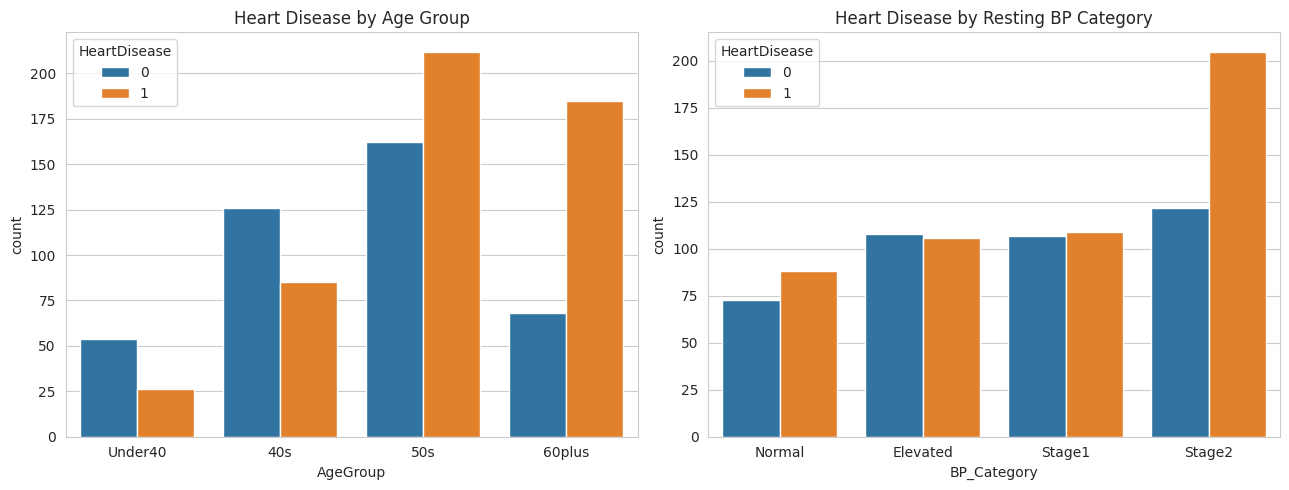

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df_fe, x='AgeGroup', hue='HeartDisease', order=['Under40','40s','50s','60plus'], ax=axes[0])
axes[0].set_title('Heart Disease by Age Group')
sns.countplot(data=df_fe, x='BP_Category', hue='HeartDisease', order=['Normal','Elevated','Stage1','Stage2'], ax=axes[1])
axes[1].set_title('Heart Disease by Resting BP Category')
plt.tight_layout()
plt.show()


## 3. Preprocessing Pipeline

In [7]:
target = 'HeartDisease'
X = df_fe.drop(columns=[target])
y = df_fe[target]

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'BP_Category', 'Cholesterol_Category', 'AgeGroup']
Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'MaxHR_Reserve', 'Chol_Age_Ratio']


In [8]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])


## 4. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (734, 16), Test shape: (184, 16)


## 5. Train Multiple Models

We train three candidate models inside a preprocessing pipeline, then compare quick holdout accuracy/F1 to pick a primary model for the evaluation notebook. Random Forest is retained as the primary model since tree-based models expose feature importances directly and typically handle this feature mix well.


In [10]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results[name] = {'accuracy': acc, 'f1': f1}
    fitted_pipelines[name] = pipe
    print(f"{name:20s} | Accuracy: {acc:.4f} | F1: {f1:.4f}")

results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
results_df


LogisticRegression   | Accuracy: 0.8913 | F1: 0.9020


RandomForest         | Accuracy: 0.8750 | F1: 0.8900


GradientBoosting     | Accuracy: 0.8913 | F1: 0.9020


,accuracy,f1
LogisticRegression,0.891304,0.901961
GradientBoosting,0.891304,0.901961
RandomForest,0.875000,0.889952


In [11]:
best_model_name = results_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
print(f"Best model selected: {best_model_name}")


Best model selected: LogisticRegression


## 6. Save Artifacts

Save the fitted pipelines and the held-out test split so `model_evaluation.ipynb` can load them directly without re-running training.


In [12]:
joblib.dump(fitted_pipelines, 'fitted_pipelines.joblib')
joblib.dump(best_model_name, 'best_model_name.joblib')

X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)

print("Artifacts saved: fitted_pipelines.joblib, best_model_name.joblib, X_train.csv, X_test.csv, y_train.csv, y_test.csv")


Artifacts saved: fitted_pipelines.joblib, best_model_name.joblib, X_train.csv, X_test.csv, y_train.csv, y_test.csv


---
**Next:** open `model_evaluation.ipynb` for classification report, confusion matrix, ROC curve, and feature importance analysis on these trained models.
